In [14]:
%load_ext autoreload
%autoreload 2
    
import polars as pl
from pathlib import Path
from tqdm.notebook import tqdm
import numpy as np
import sys
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib_config import rcparams
mpl.rcParams.update(rcparams)
import jax
from jax import numpy as jnp
from jax import random
from functools import partial
jax.config.update("jax_enable_x64", True)

sys.path.append('../src')
from robust_periodicity import clean_light_curve, unpack_light_curve
from robust_periodicity import fit_sine_wave, fourier_series_mean_function

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Finding significant periodicities (MAP-based)

The following presumes that the data was downloaded and that `periodogram_maxima`, `red_noise_laplace` and `p_value_laplace` have finished for the given experiment.

In [49]:
fbin = 0
experiment = 'gaia_qso_initial_selection_40obs_500d'
significance = 1e-5
data_folder = Path('../data/') / experiment
result_folder = Path('../results/') / f"{experiment}"
total_sources = pl.scan_parquet(data_folder / 'part_*.parquet').select(pl.len()).collect().item()
total_sources

377128

Given this significance we expect about 4 false positives

In [5]:
total_sources*significance

3.7711900000000003

How many sources are significant if we were to use the Baluev FAP estimate?

In [6]:
# How many are significant according to Baluev's rule
pl.scan_parquet(result_folder / 'periodogram_maxima').filter(pl.col('top_fap').list.get(fbin)<significance).select(pl.len()).collect().item()

305116

Certainly an over estimation, how many are significant if we use our Monte-Carlo-DRW estimated FAPs?

In [50]:
df_above_critical = pl.scan_parquet(result_folder / 'periodogram_maxima').join(
    pl.scan_parquet(result_folder / 'pval_mc_laplace'), on='sourceid'
).filter(pl.col('p_values').list.get(fbin).lt(significance)).with_columns(
    (1.0/pl.col('top_frequency').list.get(fbin)).alias('dominant_period')
).collect()
df_above_critical.height

83

However most of them have very large periods

In [8]:
df_selection = df_above_critical.with_columns(
    (pl.col('time_duration').truediv('dominant_period')).alias('num_cycles') # T/P
)
    
display(
    df_selection.with_columns(
        pl.col('num_cycles').cut([3, 1.5, 0], left_closed=True)
    ).group_by('num_cycles').len().sort('num_cycles')
)

num_cycles,len
cat,u32
"""[0, 1.5)""",79
"""[1.5, 3)""",4


In [9]:
# We save the 83 candidates for reanalysis using MCMC
save_path = Path('../data/') / 'candidates_run_laplace'
save_path.mkdir(exist_ok=True)

for file in lc_path.glob('part_*.parquet'):
    df = pl.scan_parquet(file).filter(pl.col('sourceid').is_in(df_selection['sourceid'].to_list())).collect()
    if df.height > 0:
        df.write_parquet(save_path / file.name)

How do these candidates look?

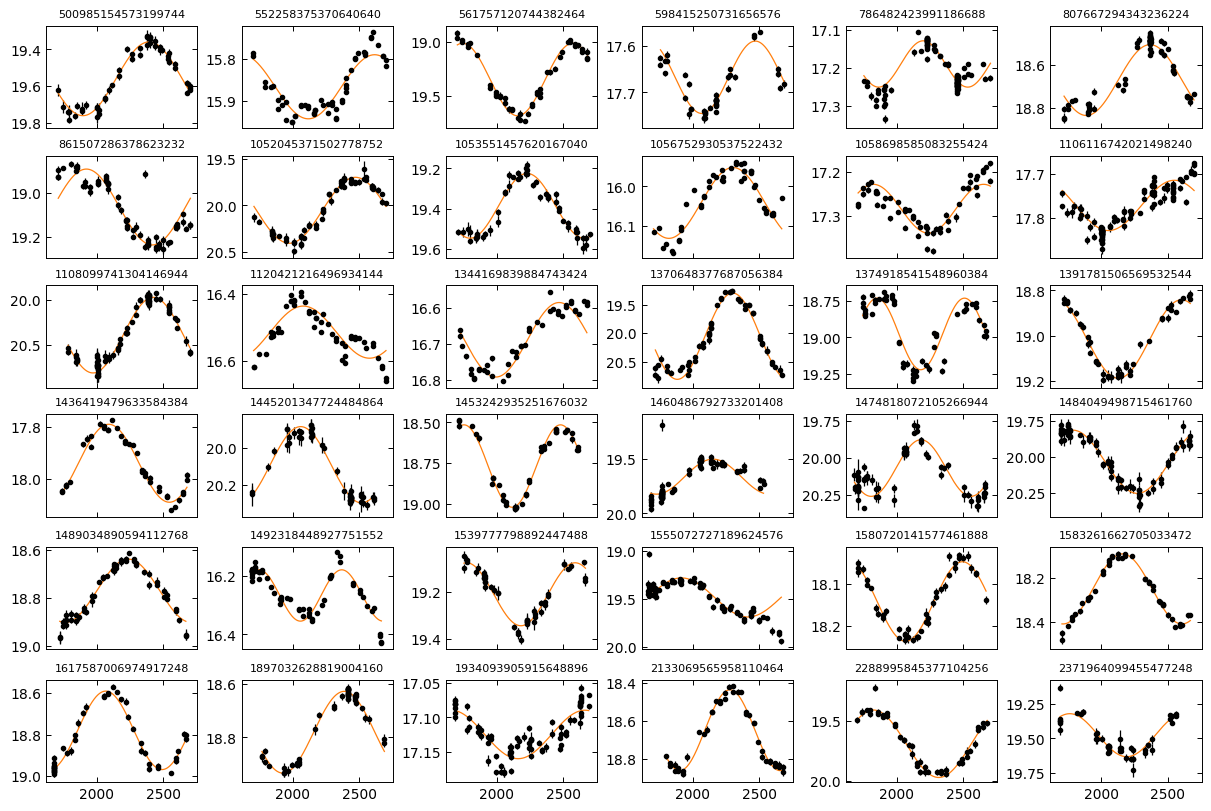

In [15]:
fig, axs = plt.subplots(6, 6, figsize=(12, 8), sharex=True, constrained_layout=True)

def get_light_curve(sid):
    return pl.scan_parquet(save_path / 'part_*.parquet').filter(pl.col('sourceid').eq(sid)).collect()
    
def fitted_sine_wave_model(time, mag, err, best_period):
    params = fit_sine_wave(time, mag, err, best_period, return_params=True)[1]
    return partial(fourier_series_mean_function, params=params, period=best_period, n_harmonics=1)

for k, ax, in enumerate(axs.ravel()):
    ex = df_selection.slice(k, 1)
    if ex.height == 0:
        continue
    sid = ex['sourceid'].item()
    best_period = ex['dominant_period'].item()
    lc = clean_light_curve(unpack_light_curve(get_light_curve(sid)), remove_extreme_errors=True, remove_extreme_values=True)
    time, mag, err = lc['g']
    time_interp = jnp.linspace(jnp.amin(time), jnp.amax(time), 500)
    per_model = jax.vmap(fitted_sine_wave_model(time, mag, err, best_period))(time=time_interp)
    ax.errorbar(time, mag, err, fmt='.', c='k')
    ax.invert_yaxis()
    ax.plot(time_interp, per_model, color='C1')
    ax.set_title(sid, fontsize=8)

And the cases with periods smaller than 1.5 the time span?

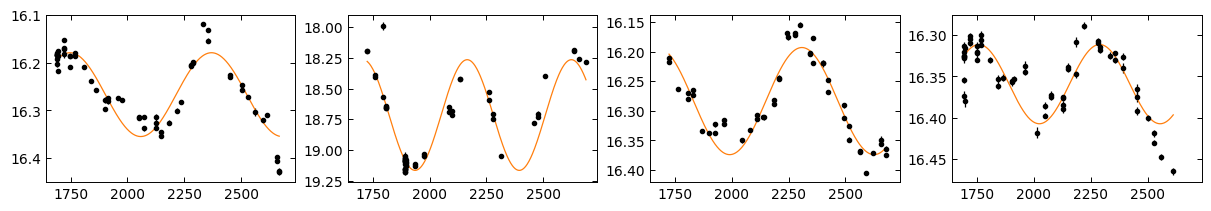

In [20]:
fig, axs = plt.subplots(1, 4, figsize=(12, 2), sharex=True, constrained_layout=True)

for k, ax, in enumerate(axs.ravel()):
    ex = df_selection.filter(pl.col('num_cycles').ge(1.5)).slice(k, 1)
    if ex.height == 0:
        continue
    sid = ex['sourceid'].item()
    best_period = ex['dominant_period'].item()
    lc = clean_light_curve(unpack_light_curve(get_light_curve(sid)))
    time, mag, err = lc['g']
    time_interp = jnp.linspace(jnp.amin(time), jnp.amax(time), 500)
    per_model = jax.vmap(fitted_sine_wave_model(time, mag, err, best_period))(time=time_interp)
    ax.errorbar(time, mag, err, fmt='.', c='k')
    ax.invert_yaxis()
    ax.plot(time_interp, per_model, color='C1')
